# MRZ EC smoother prototype (UKF / URTS)

Phase 1 (MRZ-only) data-assimilation layer over the deterministic `mrzecest`
estimator. This notebook:

1. Loads the deterministic drivers (Dayflow NDO + Martinez elevation).
2. Loads observed Martinez EC to assimilate.
3. Runs the UKF forward filter + unscented RTS smoother.
4. Punches **synthetic gaps of various lengths** and scores imputation vs
   held-out truth, comparing the smoother against the deterministic estimate.

State: `x = [log_g, b_y]` where `b_y` is a slow (OU) additive bias in
log-EC-ratio space. Kernel/g-model parameters are held **fixed** at their
fitted values (`model.yaml`); only the states are estimated.

> Run in the `schism` environment with `PYTHONPATH` including `src/` and
> `example/` on the path (for `ndo_chooser`).

In [ ]:
# Auto-reload edited modules (e.g. mrzecest.ec_filter) without restarting the kernel.
%load_ext autoreload
%autoreload 2

import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make src/ and example/ importable when running from notebooks/.
# Force these to the FRONT of sys.path so the workspace's example/ndo_chooser.py
# wins over any same-named module installed in the environment. (A plain
# "insert only if absent" guard fails when the dir is already on the path but
# ranked below site-packages.)
ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
for p in (os.path.join(ROOT, "example"), os.path.join(ROOT, "src")):
    while p in sys.path:
        sys.path.remove(p)
    sys.path.insert(0, p)

# Drop any already-imported ndo_chooser so the re-import resolves to example/.
sys.modules.pop("ndo_chooser", None)

from mrzecest.ec_filter import (
    FilterConfig,
    run_smoother,
    make_gap_mask,
    gap_metrics,
)

MODEL_YAML = os.path.join(ROOT, "example", "model.yaml")
PAD = pd.Timedelta("9D")  # elevation padding required by the filters

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Drivers and observations

- **NDO**: Dayflow at 15-min (`ndo_chooser.get_ndo`), now available through
  2025-09-30.
- **Elevation**: Martinez water level from the datastore. Elevation is a
  *deterministic driver* (never the imputation target), so small gaps are
  interpolated here to satisfy the no-NaN / padding contract.
- **EC**: observed Martinez EC (upper sensor) — the signal we assimilate.

In [66]:
# Evaluation window: fall 2024 salt season (primary out-of-sample prototype).
START = pd.Timestamp("2024-08-01")
END = pd.Timestamp("2024-12-01")

from ndo_chooser import get_ndo
from dms_datastore import read_ts_repo

ndo = get_ndo("dayflow", "15min").squeeze()
ndo = ndo.loc[START:END]

# Martinez elevation (deterministic driver). Interpolate small gaps + regularize.
elev = read_ts_repo("mrz", "elev", subloc="upper", repo="screened", force_regular=True).squeeze()
elev = elev.loc[START - PAD : END + PAD].asfreq("15min").interpolate("time")

# Observed Martinez EC (upper) to assimilate.
ec_obs = read_ts_repo("mrz", "ec", subloc="upper", repo="screened", force_regular=True).squeeze()
ec_obs = ec_obs.loc[START:END].asfreq("15min")

print("ndo", ndo.index.min(), ndo.index.max(), len(ndo))
print("elev", elev.index.min(), elev.index.max(), int(elev.isna().sum()), "NaN")
print("ec_obs", ec_obs.index.min(), ec_obs.index.max(), int(ec_obs.isna().sum()), "NaN")

ndo 2024-08-01 00:00:00 2024-12-01 00:00:00 11713
elev 2024-07-23 00:00:00 2024-12-10 00:00:00 0 NaN
ec_obs 2024-08-01 00:00:00 2024-12-01 00:00:00 0 NaN


## 2. Baseline smoother (assimilate all available EC)

The smoother should track observations where present and fall back gracefully
to the deterministic estimate where EC is missing.

In [54]:
cfg = FilterConfig(
    q_logg_per_day=0.03,   # allow modest g correction
    tau_b_days=3.0,        # bias mean-reversion timescale
    sigma_b=0.20,          # stationary bias std (log-EC-ratio)
    r_std=0.05,            # observation noise (log space)
)
res = run_smoother(ndo, elev, MODEL_YAML, ec_obs, cfg=cfg)
res.head()

,ec_obs,ec_det,ec_filt,ec_smooth,ec_lo,ec_hi,g_filt,g_smooth,b_filt,b_smooth
2024-08-01 00:00:00,32140.0,NaN,31541.472861,29915.874307,28420.308290,31490.699476,9794.731903,8144.145967,0.169766,0.029311
2024-08-01 00:15:00,29562.0,26263.334158,30561.378112,29769.026450,28430.772187,31170.719448,9846.622724,8143.970080,0.137875,0.021946
2024-08-01 00:30:00,31240.0,26679.652239,31105.529568,29995.288172,28730.555635,31316.085106,9843.615750,8143.306345,0.139937,0.015623
2024-08-01 00:45:00,27512.0,27037.847834,30133.606216,30030.604862,28808.746514,31304.647873,9851.525766,8143.224216,0.095174,0.005014
2024-08-01 01:00:00,31431.0,27308.249662,30724.232971,30278.740204,29069.120234,31539.043411,9852.843716,8141.876410,0.104941,0.004437


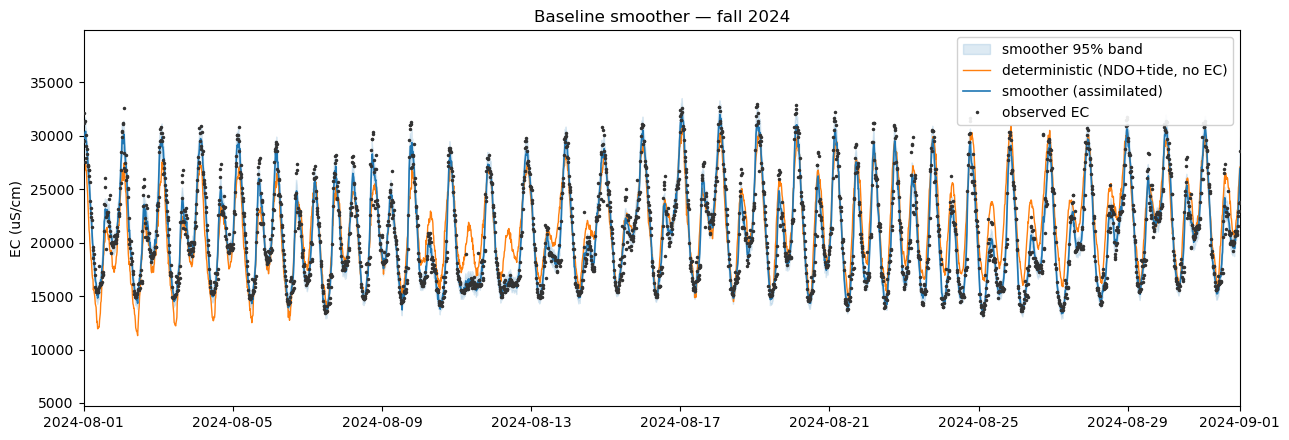

In [69]:
# Zoom window for BOTH the baseline plot and the residual plot below. Narrow these
# to zero in on specific gaps (e.g. pd.Timestamp("2024-10-01"), "2024-10-20").
start_plot = pd.Timestamp(2024,8,1) #START
end_plot = pd.Timestamp(2024,9,1) #END

fig, ax = plt.subplots(figsize=(13, 4.5))
# Draw back-to-front: band, then the two model lines, then observations on top.
ax.fill_between(res.index, res["ec_lo"], res["ec_hi"], color="tab:blue", alpha=0.15,
                label="smoother 95% band", zorder=1)
ax.plot(res.index, res["ec_det"], lw=1.0, color="tab:orange",
        label="deterministic (NDO+tide, no EC)", zorder=2)
ax.plot(res.index, res["ec_smooth"], lw=1.2, color="tab:blue",
        label="smoother (assimilated)", zorder=3)
ax.plot(res.index, res["ec_obs"], ".", ms=3, color="0.2",
        label="observed EC", zorder=4)
ax.set_xlim(start_plot, end_plot)
ax.set_ylabel("EC (uS/cm)")
ax.legend(loc="upper right", framealpha=0.9)
ax.set_title("Baseline smoother — fall 2024")
plt.tight_layout()

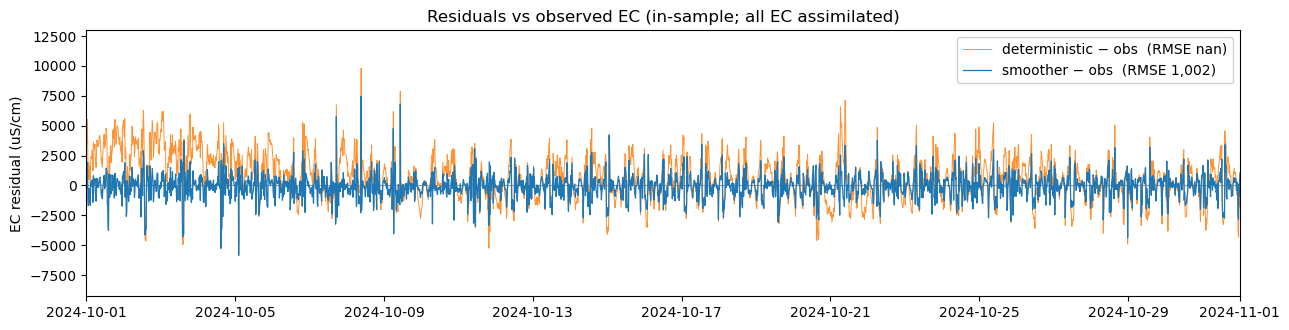

In [63]:
# Residuals vs observed EC (only where EC exists). The orange curve is how far
# the deterministic model sits from reality; the blue curve is what remains after
# assimilation. NOTE: all EC is assimilated here, so this is *in-sample* — blue is
# near zero by construction. Its value is showing the *magnitude/structure* of the
# correction (= orange residual). True skill is measured in the gap experiment below.
mask = np.isfinite(res["ec_obs"].to_numpy())
resid_det = (res["ec_det"] - res["ec_obs"])[mask]
resid_smooth = (res["ec_smooth"] - res["ec_obs"])[mask]
rmse_d = float(np.sqrt(np.mean(resid_det.to_numpy() ** 2)))
rmse_s = float(np.sqrt(np.mean(resid_smooth.to_numpy() ** 2)))

fig, ax = plt.subplots(figsize=(13, 3.4))
ax.axhline(0, color="0.6", lw=0.8)
ax.plot(resid_det.index, resid_det, lw=0.7, color="tab:orange", alpha=0.85,
        label=f"deterministic − obs  (RMSE {rmse_d:,.0f})")
ax.plot(resid_smooth.index, resid_smooth, lw=0.9, color="tab:blue",
        label=f"smoother − obs  (RMSE {rmse_s:,.0f})")
ax.set_xlim(start_plot, end_plot)
ax.set_ylabel("EC residual (uS/cm)")
ax.legend(loc="upper right", framealpha=0.9)
ax.set_title("Residuals vs observed EC (in-sample; all EC assimilated)")
plt.tight_layout()

In [ ]:
fig, ax = plt.subplots(figsize=(13, 2.6))
ax.plot(res.index, res["b_smooth"], color="tab:green", lw=1.0)
ax.axhline(0, color="0.7", lw=0.8)
ax.set_ylabel("b_y (log-EC-ratio bias)"); ax.set_title("Estimated observation bias state")
plt.tight_layout()

## 3. Synthetic-gap experiment (various lengths)

Punch gaps into the observed EC and score imputation against the held-out
truth. Gap **length** maps onto the mechanism under test:

| length | tests |
|---|---|
| ~6-12 h | tidal-phase reconstruction |
| ~1-5 d | bias persistence (smart persistence) |
| ~2-4 wk | graceful fallback to deterministic |

`rmse` is the smoother error over held-out samples; `rmse_det` is the
deterministic estimate over the same samples (the baseline to beat).

In [72]:
# Only hold out where we actually have truth to score against.
from vtools import cosine_lanczos  # 40h subtidal low-pass

truth = ec_obs.copy()
valid_idx = res.index[np.isfinite(truth.reindex(res.index).to_numpy())]
truth_sub = cosine_lanczos(truth.reindex(res.index), "40h").to_numpy()  # "true" subtidal EC

gap_specs = [
    ("short_6h",  [("6h", 8)]),
    ("med_2d",    [("2D", 4)]),
    ("med_5d",    [("5D", 2)]),
    ("long_21d",  [("21D", 1)]),
]

rows = []
for name, gaps in gap_specs:
    held = make_gap_mask(res.index, gaps=gaps, seed=hash(name) % 2**32)
    held &= pd.Series(res.index.isin(valid_idx), index=res.index)  # only scoreable
    ec_gapped = truth.copy()
    ec_gapped[held.to_numpy()] = np.nan
    r = run_smoother(ndo, elev, MODEL_YAML, ec_gapped, cfg=cfg)
    stats = gap_metrics(r, truth, held)
    # Subtidal (40h low-pass) skill isolates the subtidal correction from the
    # tidal-band misfit floor. Scored over held-out samples.
    sm_sub = cosine_lanczos(r["ec_smooth"], "40h").to_numpy()
    det_sub = cosine_lanczos(r["ec_det"], "40h").to_numpy()
    mh = held.to_numpy() & np.isfinite(truth_sub) & np.isfinite(sm_sub)
    stats["rmse_sub"] = float(np.sqrt(np.mean((sm_sub[mh] - truth_sub[mh]) ** 2)))
    stats["rmse_sub_det"] = float(np.sqrt(np.mean((det_sub[mh] - truth_sub[mh]) ** 2)))
    stats["case"] = name
    rows.append(stats)

summary = pd.DataFrame(rows).set_index("case")
summary[["n", "rmse", "rmse_det", "rmse_sub", "rmse_sub_det", "rmse_log"]]

,n,rmse,rmse_det,rmse_sub,rmse_sub_det,rmse_log
case,,,,,,
short_6h,192,2074.472860,2101.788845,299.560741,1802.947716,0.084001
med_2d,768,2264.338395,2690.844989,1268.139441,2106.706808,0.100793
med_5d,960,2015.993617,2682.405255,1020.497640,2040.290544,0.084902
long_21d,2016,2338.045006,2831.311761,1315.678902,2105.956355,0.108218


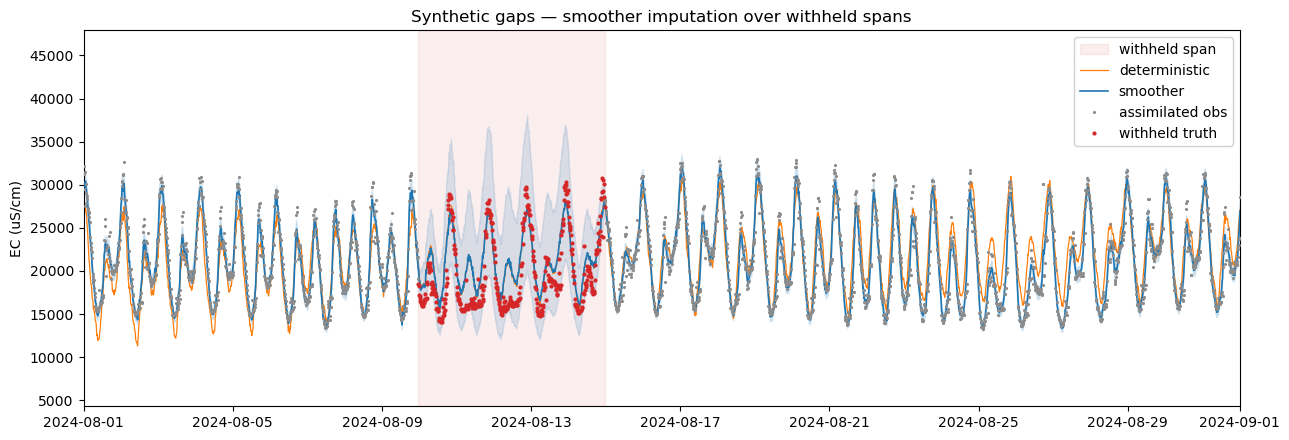

In [71]:
# Visualize one medium-gap case: smoother imputation across the gaps.
held = make_gap_mask(res.index, gaps=[("5D", 2)], seed=123)
held &= pd.Series(res.index.isin(valid_idx), index=res.index)
ec_gapped = truth.copy(); ec_gapped[held.to_numpy()] = np.nan
rg = run_smoother(ndo, elev, MODEL_YAML, ec_gapped, cfg=cfg)

held_np = held.to_numpy()
fig, ax = plt.subplots(figsize=(13, 4.5))
# Shade the withheld spans so gaps are obvious (uses axis-fraction y).
ax.fill_between(rg.index, 0, 1, where=held_np, transform=ax.get_xaxis_transform(),
                color="tab:red", alpha=0.08, label="withheld span")
ax.fill_between(rg.index, rg["ec_lo"], rg["ec_hi"], color="tab:blue", alpha=0.15, zorder=1)
ax.plot(rg.index, rg["ec_det"], lw=0.9, color="tab:orange", label="deterministic", zorder=2)
ax.plot(rg.index, rg["ec_smooth"], lw=1.2, color="tab:blue", label="smoother", zorder=3)
# Assimilated (seen) obs in gray; withheld truth highlighted in red on top.
ax.plot(rg.index, ec_gapped.reindex(rg.index), ".", ms=2.5, color="0.55",
        label="assimilated obs", zorder=4)
ax.plot(rg.index[held_np], truth.reindex(rg.index).to_numpy()[held_np], ".", ms=4,
        color="tab:red", label="withheld truth", zorder=5)
ax.set_xlim(start_plot, end_plot)
ax.set_ylabel("EC (uS/cm)")
ax.legend(loc="upper right", framealpha=0.9)
ax.set_title("Synthetic gaps — smoother imputation over withheld spans")
plt.tight_layout()

## 4. Notes / next steps

- **Fall 2025** (through 2025-09-30) is available as a second out-of-sample
  season — rerun sections 1-3 with `START/END` shifted.
- **Negative control**: rerun on a fresh spring stretch and confirm the
  smoother does not fabricate salt when `g` is unobservable.
- **Phase 1b**: swap the observation bias `b_y` for a flow bias `b_q` on the
  modified NDO ("right model, wrong flow") and compare.
- **Benicia (later)**: add a second EC kernel on the shared `g` with a
  fouling/outlier-robust observation mode.